#Diabetes Risk Predictive Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
df=pd.read_csv('/content/diabetes_012_health_indicators_BRFSS2015.csv')

In [3]:
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [5]:
df.columns

Index(['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

In [6]:
df.isnull().sum()

,0
Diabetes_012,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,0
Fruits,0


In [7]:
duplicates = df.duplicated().sum()
print(f'Number of duplicate entries: {duplicates}')

Number of duplicate entries: 23899


In [8]:
data_cleaned = df.drop_duplicates()
print(f'Number of entries after removing duplicates: {len(data_cleaned)}')

Number of entries after removing duplicates: 229781


/tmp/ipykernel_33741/917513342.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Diabetes_012', data=df, palette='viridis')


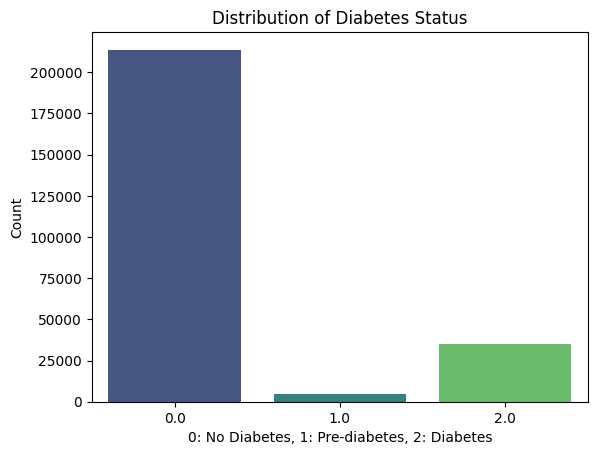

In [9]:
sns.countplot(x='Diabetes_012', data=df, palette='viridis')
plt.title('Distribution of Diabetes Status')
plt.xlabel('0: No Diabetes, 1: Pre-diabetes, 2: Diabetes')
plt.ylabel('Count')
plt.show()

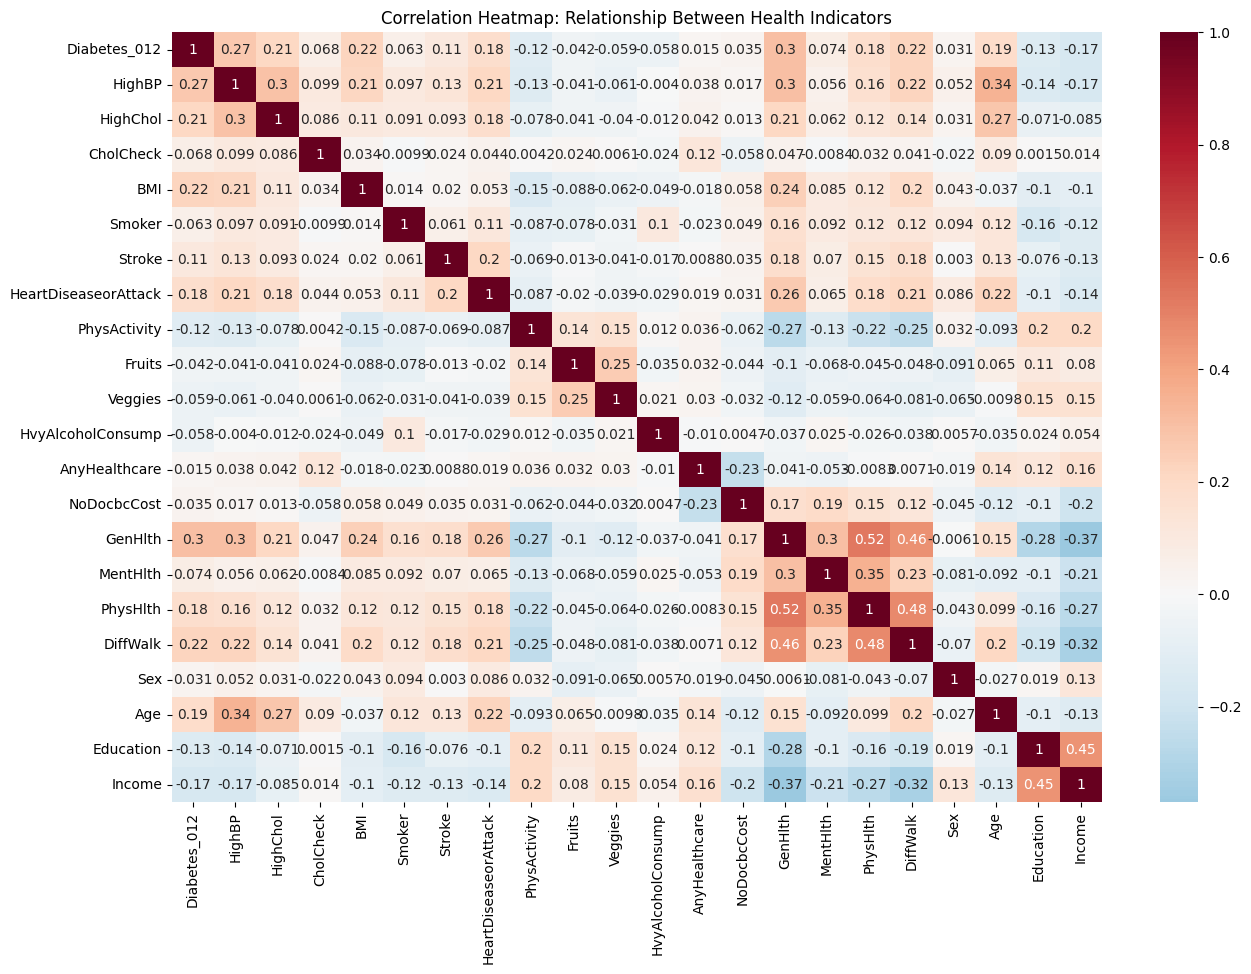

In [10]:
plt.figure(figsize=(15, 10))
# Calculate correlation
corr = df.corr()
# Create heatmap
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0)
plt.title('Correlation Heatmap: Relationship Between Health Indicators')
plt.show()

#High Blood Pressure vs. Diabetes

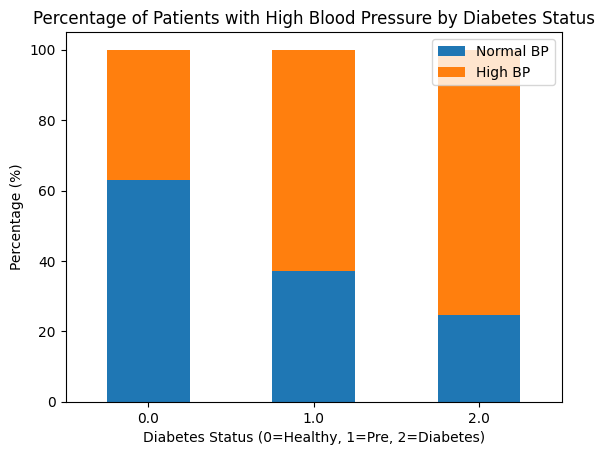

In [11]:
blood_pressure_data = df.groupby('Diabetes_012')['HighBP'].value_counts(normalize=True).unstack() * 100
blood_pressure_data.plot(kind='bar', stacked=True, color=['#1f77b4', '#ff7f0e'])
plt.title('Percentage of Patients with High Blood Pressure by Diabetes Status')
plt.ylabel('Percentage (%)')
plt.xlabel('Diabetes Status (0=Healthy, 1=Pre, 2=Diabetes)')
plt.legend(['Normal BP', 'High BP'], loc='upper right')
plt.xticks(rotation=0)
plt.show()

In [12]:
X = df.drop('Diabetes_012', axis=1)
y = df['Diabetes_012']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [15]:
pred = log_model.predict(X_test)
print(f"Logistic Regression Accuracy: {accuracy_score(y_test,pred):.2%}")
print("\nClassification Report:")
print(classification_report(y_test,pred))

Logistic Regression Accuracy: 84.83%

Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.98      0.92     42795
         1.0       0.00      0.00      0.00       944
         2.0       0.54      0.18      0.27      6997

    accuracy                           0.85     50736
   macro avg       0.47      0.39      0.40     50736
weighted avg       0.80      0.85      0.81     50736



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [16]:
X = df.drop('Diabetes_012', axis=1)
y = df['Diabetes_012']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)
print("Model training complete!")

Model training complete!


In [19]:
predictions = model.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, predictions))

Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.99      0.92     42795
         1.0       0.00      0.00      0.00       944
         2.0       0.59      0.12      0.20      6997

    accuracy                           0.85     50736
   macro avg       0.48      0.37      0.37     50736
weighted avg       0.80      0.85      0.80     50736



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


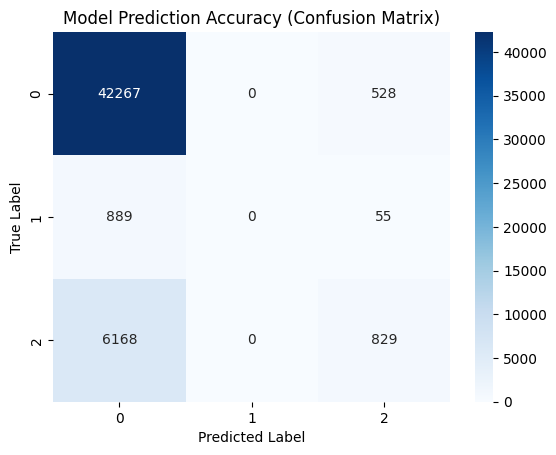

In [20]:
#Visualize the Confusion Matrix
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='d', cmap='Blues')
plt.title('Model Prediction Accuracy (Confusion Matrix)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

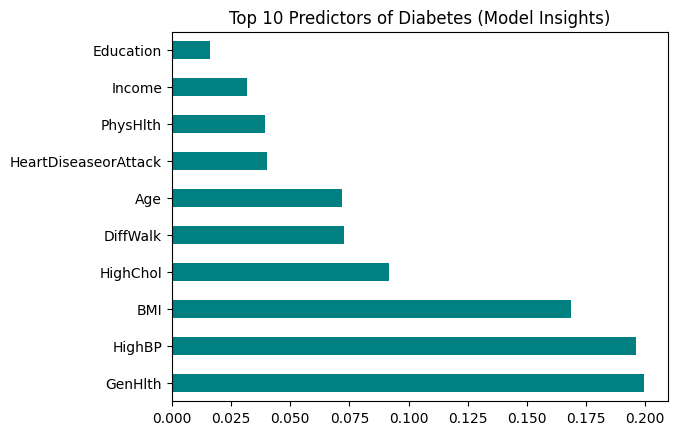

In [21]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 Predictors of Diabetes (Model Insights)')
plt.show()

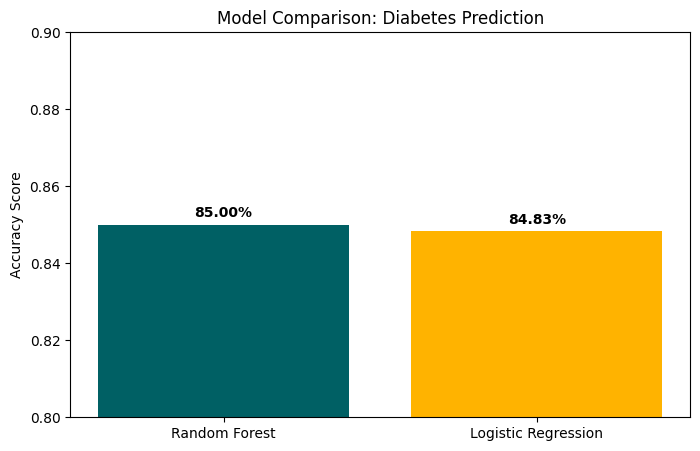

In [22]:
models = ['Random Forest', 'Logistic Regression']
accuracies = [0.85, 0.8483]
plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=['#006064', '#FFB300'])
plt.ylim(0.8, 0.9)
plt.ylabel('Accuracy Score')
plt.title('Model Comparison: Diabetes Prediction')
# Adding the exact percentage on top of the bars
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.002, f"{v*100:.2f}%", ha='center', fontweight='bold')
plt.show()

#SUMMARY

In [23]:
data = {
    'Model': ['Random Forest', 'Logistic Regression'],
    'Accuracy (%)': [85.00, 84.83],
    'Precision (Class 0)': [0.86, 0.86],
    'Recall (Class 0)': [0.99, 0.98]
}
summary_df = pd.DataFrame(data)
print("--- Final Model Comparison ---")
print(summary_df)

--- Final Model Comparison ---
                 Model  Accuracy (%)  Precision (Class 0)  Recall (Class 0)
0        Random Forest         85.00                 0.86              0.99
1  Logistic Regression         84.83                 0.86              0.98


In [24]:
df.to_csv('diabetes_for_powerbi.csv', index=False)
print("✅ CSV saved! Go to the folder icon on the left in Colab to download it.")

✅ CSV saved! Go to the folder icon on the left in Colab to download it.
